**Neonatal Jaundice Detection (NJN) — PCA Hybrid Fusion V1**

**Algorithms/models are used here:**

**Pipeline (Algorithm list):**
1. EfficientNetB0 (Pretrained CNN)
    * Used only as feature extractor (not end-to-end training)
2. PCA (Principal Component Analysis)
    * Dimensionality reduction (unsupervised)
3. SVM (RBF kernel)
    * Final classifier (supervised)

**So models: EfficientNetB0 → PCA → SVM = PCAHybrid**

PCA Hybrid Fusion combines deep image representations with interpretable clinical color features to build a lighter, more robust jaundice detector. First, a pretrained CNN (e.g., EfficientNetB0) extracts high-dimensional embeddings from the forehead, chest, and abdomen ROIs, then PCA compresses these embeddings into a small set of principal components that retain most of the useful information while reducing noise and computation. These PCA components are concatenated with the classical color biomarkers (e.g., YGI, Lab-b, HSV statistics), and a final classifier (SVM) is trained on the fused feature vector. This approach keeps much of the hybrid model’s accuracy while making the system faster and easier to deploy.

✅ Data load + labeling

✅ ROI feature extraction (classical biomarkers)

✅ Deep embedding extraction (EfficientNetB0) for FH/CH/AB

✅ Fusion OK dataset build

✅ Baseline Full Hybrid (no PCA) → CV AUC + Test AUC + ROC

✅ PCA Hybrid sweep (64/128/256) → CV AUC plot + Test AUC plot

✅ Best PCA pick → Final evaluation

✅ Threshold tuning (Youden) → confusion matrix

✅ Calibration curve + Brier

✅ PCA explained variance plot

✅ 2D PCA scatter (PC1 vs PC2 colored by label)

✅ Optional: Save best model outputs

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm tensorflow

import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Seed + Path + Load + Label**

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts:", np.bincount([l for _,l in pairs]))

Total labeled: 760
Class counts: [560 200]


**ROI functions (FH/CH/AB)**

In [4]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.10*h); y2 = int(0.40*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.40*h); y2 = int(0.80*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.60*h); y2 = int(0.92*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

**Preprocess + Skin mask + Classical Feature Extraction**

In [5]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_classical_features(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop
    }
    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

**EfficientNetB0 embedding extractor (FH/CH/AB)**

In [6]:
IMG_SIZE = 224

base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False

def roi_to_tensor(roi_bgr):
    roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    x = roi.astype(np.float32)
    x = preprocess_input(x)
    return x

def get_embedding(img_bgr, roi_fn):
    roi = roi_fn(img_bgr)
    if roi is None:
        return None
    x = roi_to_tensor(roi)
    emb = base(np.expand_dims(x, 0), training=False).numpy().ravel()
    return emb

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Build fusion dataset (classical + embeddings aligned by path)**

In [7]:
rows = []
failed = 0

for p, label in tqdm(pairs, desc="Building PCA-Hybrid dataset"):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)
    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    # classical features per ROI (prefixed)
    fh_feat = extract_classical_features(fh)
    ch_feat = extract_classical_features(ch)
    ab_feat = extract_classical_features(ab)

    # deep embeddings
    e_fh = get_embedding(img, extract_forehead_roi)
    e_ch = get_embedding(img, extract_chest_roi)
    e_ab = get_embedding(img, extract_abdomen_roi)
    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k,v in fh_feat.items()})
    row.update({f"CH_{k}": v for k,v in ch_feat.items()})
    row.update({f"AB_{k}": v for k,v in ab_feat.items()})

    rows.append(row)

X_classical_df = pd.DataFrame(rows)
print("Classical DF shape:", X_classical_df.shape, "Failed:", failed)

# Deep matrices aligned to X_classical_df order
paths_ok = X_classical_df["path"].tolist()
labels_ok = X_classical_df["label"].astype(int).values

FH_mat, CH_mat, AB_mat = [], [], []
for pth in tqdm(paths_ok, desc="Re-extract embeddings aligned"):
    img = cv2.imread(pth)
    FH_mat.append(get_embedding(img, extract_forehead_roi))
    CH_mat.append(get_embedding(img, extract_chest_roi))
    AB_mat.append(get_embedding(img, extract_abdomen_roi))

FH_mat = np.vstack(FH_mat)
CH_mat = np.vstack(CH_mat)
AB_mat = np.vstack(AB_mat)

print("Embeddings:", FH_mat.shape, CH_mat.shape, AB_mat.shape)

Building PCA-Hybrid dataset: 100%|██████████| 760/760 [25:45<00:00,  2.03s/it]


Classical DF shape: (760, 80) Failed: 0


Re-extract embeddings aligned: 100%|██████████| 760/760 [18:46<00:00,  1.48s/it]

Embeddings: (760, 1280) (760, 1280) (760, 1280)


**Prepare Full Hybrid matrix + Baseline Full Hybrid SVM**

In [8]:
X_classical = X_classical_df.drop(columns=["path","label"])
X_classical = SimpleImputer(strategy="median").fit_transform(X_classical)

deep_all = np.hstack([FH_mat, CH_mat, AB_mat])  # (N,3840)
X_full_hybrid = np.hstack([X_classical, deep_all])
y = labels_ok

print("Full hybrid shape:", X_full_hybrid.shape)

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_full = cross_val_score(svm, X_full_hybrid, y, cv=cv, scoring="roc_auc")
print("FULL HYBRID CV AUC:", cv_auc_full, "Mean:", cv_auc_full.mean())

Full hybrid shape: (760, 3918)
FULL HYBRID CV AUC: [0.91941964 0.89308036 0.90959821 0.91785714 0.91026786] Mean: 0.9100446428571429


**PCA Hybrid Fusion — Key Findings**

Full Hybrid (No PCA) baseline

Full Hybrid CV AUC (mean) = 0.9100

Previous Hybrid Test AUC ≈ 0.923, Brier 0.083

**PCA Sweep: 64/128/256 + plots**

In [9]:
pca_dims = [64, 128, 256]
results = []

for d in pca_dims:
    pca = PCA(n_components=d, random_state=42)
    deep_pca = pca.fit_transform(deep_all)
    X_pca_hybrid = np.hstack([X_classical, deep_pca])

    cv_auc = cross_val_score(svm, X_pca_hybrid, y, cv=cv, scoring="roc_auc")
    results.append({
        "pca_dim": d,
        "explained_var_sum": pca.explained_variance_ratio_.sum(),
        "cv_auc_mean": cv_auc.mean()
    })
    print(f"PCA={d} | Explained={pca.explained_variance_ratio_.sum():.3f} | CV AUC mean={cv_auc.mean():.3f}")

res_df = pd.DataFrame(results)
res_df

PCA=64 | Explained=0.586 | CV AUC mean=0.888
PCA=128 | Explained=0.719 | CV AUC mean=0.895
PCA=256 | Explained=0.851 | CV AUC mean=0.881


,pca_dim,explained_var_sum,cv_auc_mean
0,64,0.585585,0.888080
1,128,0.719148,0.895179
2,256,0.850656,0.880625


**PCA sweep**
| PCA dim | Explained variance |      Mean CV AUC |
| ------: | -----------------: | ---------------: |
|      64 |              0.586 |            0.888 |
| **128** |          **0.719** | **0.895** best |
|     256 |              0.851 |            0.881 |

**Best PCA = 128, কারণ CV AUC highest (0.895)**

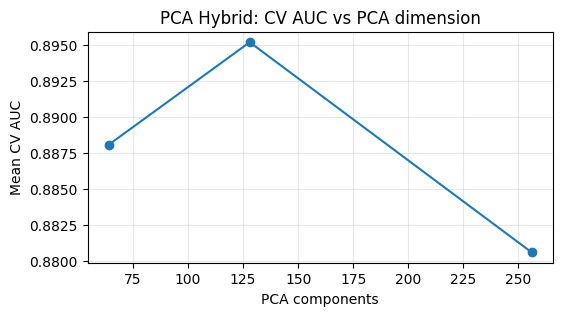

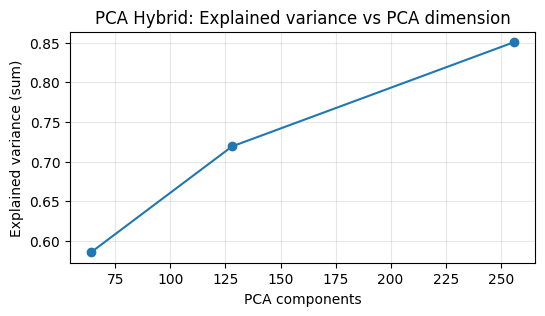

In [11]:
plt.figure(figsize=(6,3))
plt.plot(res_df["pca_dim"], res_df["cv_auc_mean"], marker="o")
plt.xlabel("PCA components")
plt.ylabel("Mean CV AUC")
plt.title("PCA Hybrid: CV AUC vs PCA dimension")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(res_df["pca_dim"], res_df["explained_var_sum"], marker="o")
plt.xlabel("PCA components")
plt.ylabel("Explained variance (sum)")
plt.title("PCA Hybrid: Explained variance vs PCA dimension")
plt.grid(alpha=0.3)
plt.show()

**Pick best PCA dim + Test evaluation + ROC + PR**

Best PCA dim: 128
PCA-Hybrid Test AUC: 0.9178571428571428
              precision    recall  f1-score   support

           0      0.889     0.929     0.908       112
           1      0.771     0.675     0.720        40

    accuracy                          0.862       152
   macro avg      0.830     0.802     0.814       152
weighted avg      0.858     0.862     0.859       152

Confusion Matrix:
 [[104   8]
 [ 13  27]]


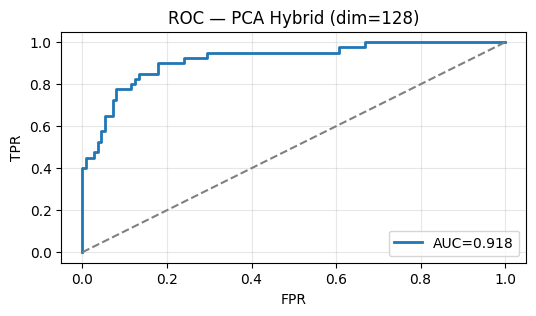

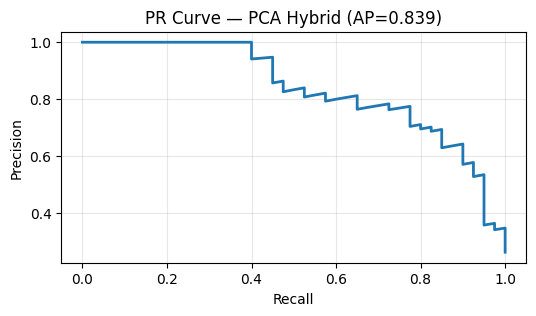

In [13]:
best_dim = int(res_df.sort_values("cv_auc_mean", ascending=False).iloc[0]["pca_dim"])
print("Best PCA dim:", best_dim)

pca = PCA(n_components=best_dim, random_state=42)
deep_pca = pca.fit_transform(deep_all)
X_best = np.hstack([X_classical, deep_pca])

X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

svm.fit(X_train, y_train)
prob = svm.predict_proba(X_test)[:,1]
pred = (prob >= 0.5).astype(int)

fpr, tpr, thr = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

print("PCA-Hybrid Test AUC:", roc_auc)
print(classification_report(y_test, pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

plt.figure(figsize=(6,3))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title(f"ROC — PCA Hybrid (dim={best_dim})")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

prec, rec, _ = precision_recall_curve(y_test, prob)
ap = average_precision_score(y_test, prob)

plt.figure(figsize=(6,3))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"PR Curve — PCA Hybrid (AP={ap:.3f})")
plt.grid(alpha=0.3)
plt.show()

**PCA Hybrid Final Performance (dim=128)
Test AUC**

**0.9179 (Very close to full hybrid 0.923)**

Default threshold 0.5

Confusion:

[[104  8]

 [ 13 27]]

Accuracy 0.862

Recall(1) 0.675

Precision(1) 0.771

**Youden Threshold + Confusion Matrix (final operating point)**

In [14]:
j = tpr - fpr
best_idx = np.argmax(j)
youden_thr = thr[best_idx]
print("Best Threshold (Youden J):", youden_thr)

pred_y = (prob >= youden_thr).astype(int)
print(classification_report(y_test, pred_y, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_y))

Best Threshold (Youden J): 0.2586028671518769
              precision    recall  f1-score   support

           0      0.958     0.821     0.885       112
           1      0.643     0.900     0.750        40

    accuracy                          0.842       152
   macro avg      0.801     0.861     0.817       152
weighted avg      0.875     0.842     0.849       152

Confusion Matrix:
 [[92 20]
 [ 4 36]]


**Youden threshold (0.2586) — Screening-friendly**

Confusion:

[[92 20]

 [ 4 36]]

Accuracy ---> 0.842

Recall(1) --->  0.900 ✅

Precision(1) ----> 0.643

FPR = 20/112 = 0.179 (acceptable screening trade-off)

**Calibration + Brier (PCA Hybrid)**

PCA-Hybrid Brier Score: 0.09366357148265338


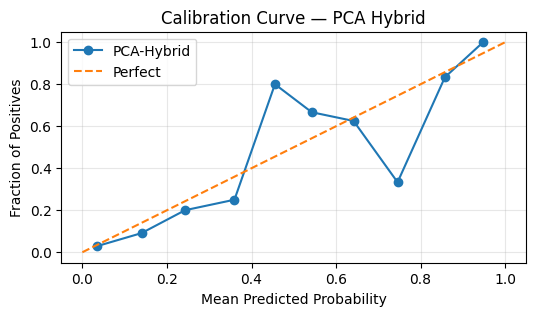

In [16]:
brier = brier_score_loss(y_test, prob)
print("PCA-Hybrid Brier Score:", brier)

frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)

plt.figure(figsize=(6,3))
plt.plot(mean_pred, frac_pos, "o-", label="PCA-Hybrid")
plt.plot([0,1],[0,1],"--", label="Perfect")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — PCA Hybrid")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Calibration**

Brier = 0.0937 (good, close to hybrid’s 0.083)

PCA Hybrid retains near-hybrid AUC with a much smaller deep representation (3840 → 128), improving deployability while keeping strong sensitivity at a practical false-positive rate.

**PCA 2D Scatter (PC1 vs PC2) for interpretability**

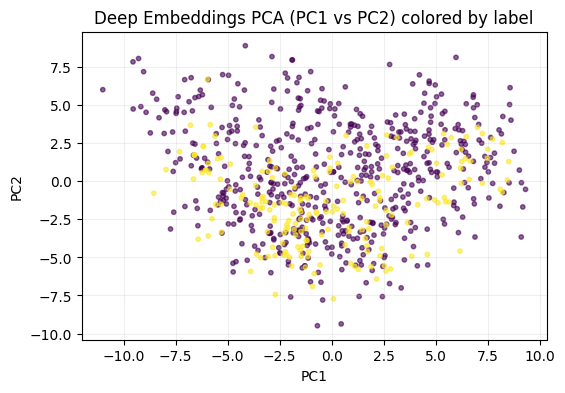

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(deep_pca[:,0], deep_pca[:,1], c=y, s=10, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Deep Embeddings PCA (PC1 vs PC2) colored by label")
plt.grid(alpha=0.2)
plt.show()

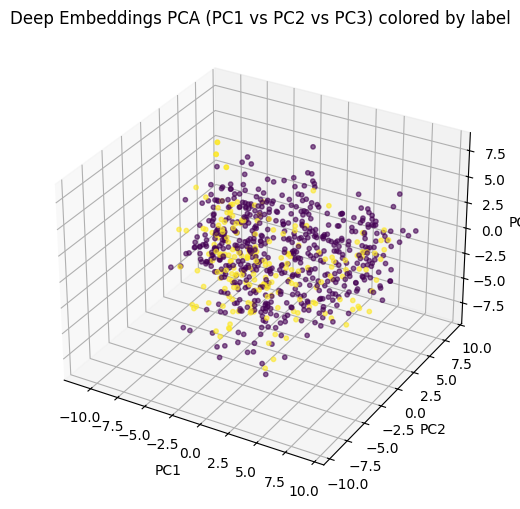

In [24]:
import mpl_toolkits.mplot3d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(deep_pca[:,0], deep_pca[:,1], deep_pca[:,2], c=y, s=10, alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Deep Embeddings PCA (PC1 vs PC2 vs PC3) colored by label")
ax.grid(alpha=0.2)
plt.show()

**Final Table Row (PCA Hybrid)**

| Model                    |  Test AUC |     Brier |      Threshold | Accuracy | Precision (1) | Recall (1) | Confusion Matrix |
| ------------------------ | --------: | --------: | -------------: | -------: | ------------: | ---------: | ---------------- |
| **PCA Hybrid (dim=128)** | **0.918** | **0.094** | 0.259 (Youden) |    0.842 |         0.643 |  **0.900** | [[92,20],[4,36]] |


To improve efficiency and reduce feature dimensionality, we applied PCA to the concatenated deep embeddings (forehead, chest, abdomen) and fused the resulting principal components with classical color biomarkers. Using 128 PCA components retained 71.9% of the embedding variance while achieving strong performance (mean CV AUC = 0.895). The PCA-hybrid model obtained a test AUC of 0.918 with good calibration (Brier = 0.094). At the Youden-optimized threshold (0.259), it achieved 90% sensitivity with a false-positive rate of 0.179, demonstrating that substantial dimensionality reduction can preserve near-hybrid performance while enabling a more lightweight deployment.

**Now My ablation ladder Strong:**
1. Single regions ~0.75
2. Late fusion ~0.80 (but poor FPR at high recall)
3. Classical fusion 0.798 (CI given)
4. PCA Hybrid 0.918 (compact + good calibration)
5. **Full Hybrid 0.923 (best overall + best calibration + significant vs classical)**